In [15]:
import pandas as pd
import networkx as nx
import numpy as np

# NetworkX

In [16]:
df = pd.read_csv('enron_weighted_edges.csv')

x = df['Source'].to_list()
y = df['Target'].to_list()
weight = df['Weight'].to_list()

#edge list
edges=[]

for i in range(len(x)):
    edges.append((x[i],y[i],weight[i]))

In [17]:
G = nx.DiGraph()

nodes = np.arange(1,56955,1)

G.add_nodes_from(nodes)
G.add_weighted_edges_from(edges)

Network Summary

In [18]:
print('No. of nodes in the graph: ', G.order())
print('No. of edges in the graph: ',G.number_of_edges())
print('Network density: ',nx.density(G))
print('Is directed? ',G.is_directed())

No. of nodes in the graph:  56954
No. of edges in the graph:  228069
Network density:  7.031134762715852e-05
Is directed?  True


# Task 1

Degree Summary

In [19]:
# --- Degree ---
print(f"Average Degree = {( np.array([x[1] for x in G.degree(weight='weight')]).mean())}")
print(f"Average In-degree = {( np.array([x[1] for x in G.in_degree(weight='weight')]).mean())}")
print(f"Average Out-degree = {( np.array([x[1] for x in G.out_degree(weight='weight')]).mean())}\n")

# --- In-Degree ---
in_degrees = dict(G.in_degree())



max_in_node = max(in_degrees, key=in_degrees.get)
min_in_node = min(in_degrees, key=in_degrees.get)

# --- Out-Degree ---
out_degrees = dict(G.out_degree())

max_out_node = max(out_degrees, key=out_degrees.get)
min_out_node = min(out_degrees, key=out_degrees.get)

# --- Print Results ---
print(f"Maximum In-Degree Node: {max_in_node} with in-degree: {in_degrees[max_in_node]}")
print(f"Minimum In-Degree Node: {min_in_node} with in-degree: {in_degrees[min_in_node]}\n")

print(f"Maximum Out-Degree Node:{max_out_node} with out-degree: {out_degrees[max_out_node]}")
print(f"Minimum Out-Degree Node: {min_out_node} with out-degree:  {out_degrees[min_out_node]}")



Average Degree = 34.5214032377006
Average In-degree = 17.2607016188503
Average Out-degree = 17.2607016188503

Maximum In-Degree Node: 3266 with in-degree: 764
Minimum In-Degree Node: 70 with in-degree: 0

Maximum Out-Degree Node:1219 with out-degree: 1284
Minimum Out-Degree Node: 9 with out-degree:  0


Subgraph degree>=9

In [20]:
node_list = np.array([])

for x in G.degree():
    if x[1]>=10:
        node_list=np.append(node_list,int(x[0]))

G_sub = G.subgraph(node_list)

print('Sub graph of degree>=10:')
print(f'Number of nodes {G_sub.number_of_nodes()}')
print(f'Number of edges {G_sub.number_of_edges()}')
print(f"Average In-degree = {( np.array([x[1] for x in G_sub.in_degree(weight='weight')]).mean())}")
print(f"Average Out-degree = {( np.array([x[1] for x in G_sub.out_degree(weight='weight')]).mean())}\n")

Sub graph of degree>=10:
Number of nodes 6368
Number of edges 141528
Average In-degree = 121.03015075376885
Average Out-degree = 121.03015075376885



In [21]:
undirected_G_sub = G_sub.to_undirected()
avg_clustering = nx.average_clustering(undirected_G_sub)

print('\nAverage Clustering Coefficient: ',avg_clustering)


Average Clustering Coefficient:  0.38887991450181136


In [22]:
bc_G_sub = nx.betweenness_centrality(G_sub)

sorted_bc = sorted(bc_G_sub.items(), key=lambda x:x[1], reverse=True)

print("\nTop 10 Betweenness Centrality Nodes:")
for node,score in enumerate(sorted_bc[:10],1):
    print(node,score)


Top 10 Betweenness Centrality Nodes:
1 (np.float64(585.0), 0.07269274350659133)
2 (np.float64(3266.0), 0.04488105249284574)
3 (np.float64(1219.0), 0.03494432495260772)
4 (np.float64(5556.0), 0.03410200125424431)
5 (np.float64(4377.0), 0.03129585587782864)
6 (np.float64(4390.0), 0.02874764134221738)
7 (np.float64(4404.0), 0.026213917510177098)
8 (np.float64(3207.0), 0.021548461290405288)
9 (np.float64(1.0), 0.01771987978634681)
10 (np.float64(3631.0), 0.01701285945111718)


In [23]:
cc_G_sub = nx.closeness_centrality(G_sub)

sorted_cc = sorted(cc_G_sub.items(), key=lambda x:x[1], reverse=True)

print("\nTop 10 Closeness Centrality Nodes:")
for node, score in enumerate(sorted_cc[:10],1):
    print(node,score)


Top 10 Closeness Centrality Nodes:
1 (np.float64(1070.0), 0.29921642018643696)
2 (np.float64(998.0), 0.2974625138547462)
3 (np.float64(609.0), 0.2940440648785304)
4 (np.float64(4377.0), 0.29384542480382)
5 (np.float64(3207.0), 0.2937603754768145)
6 (np.float64(521.0), 0.2922098168730501)
7 (np.float64(925.0), 0.28973511198184243)
8 (np.float64(1406.0), 0.2883085211454581)
9 (np.float64(3266.0), 0.2872748647813173)
10 (np.float64(1393.0), 0.28700408066897753)


In [24]:
pos = nx.spring_layout(G_sub.to_undirected(), k=0.15, iterations=20)

In [25]:
sorted_bc = sorted(bc_G_sub.items(), key=lambda x: x[1], reverse=True)[:100]
sorted_cc = sorted(cc_G_sub.items(), key=lambda x: x[1], reverse=True)[:100]

bc_nodes = [node for node, score in sorted_bc]
bc_sizes = [5000 * score for node, score in sorted_bc]

cc_nodes = [node for node, score in sorted_cc]
cc_sizes = [5000 * score for node, score in sorted_cc]


labels_bc = {node: node for node in bc_nodes}
labels_cc = {node: node for node in cc_nodes}

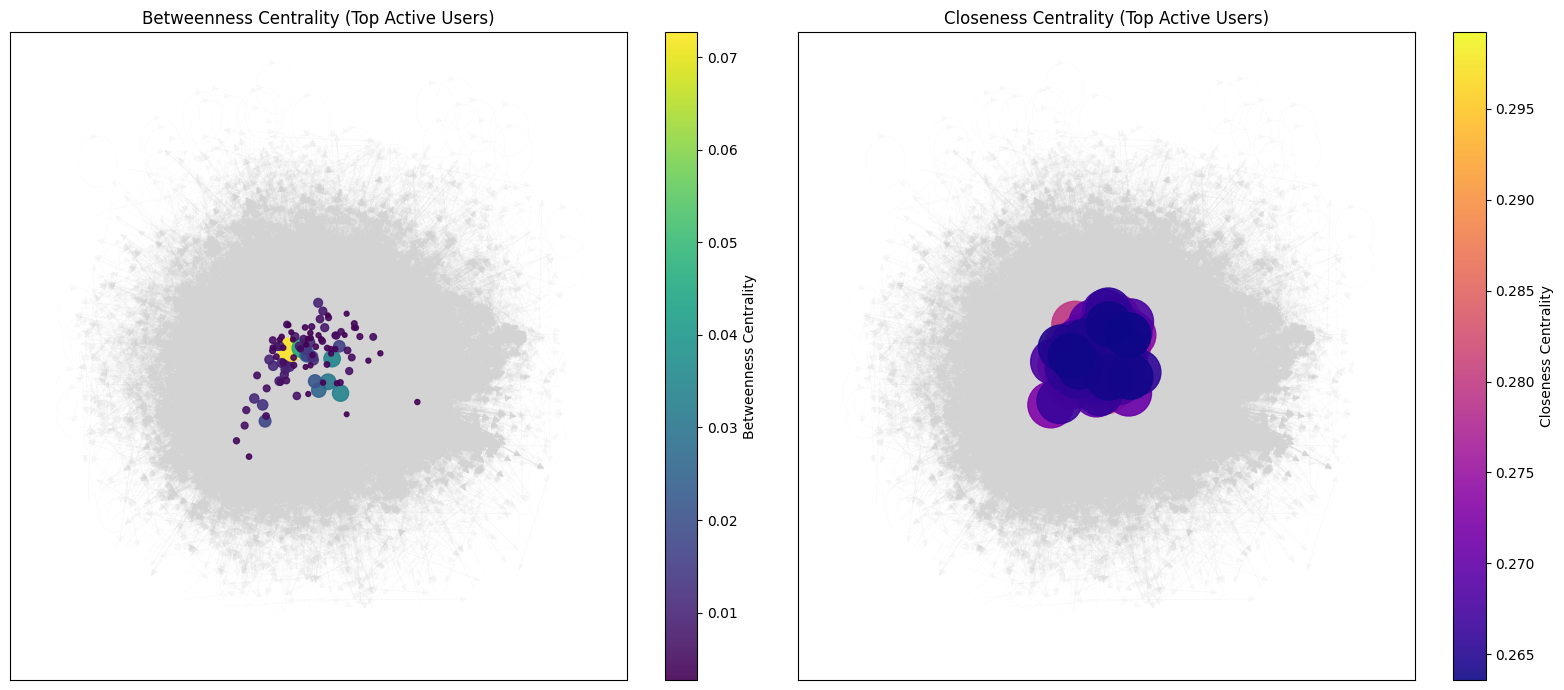

: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

# ---------- Betweenness Centrality ----------
axes[0].set_title("Betweenness Centrality (Top Active Users)")

bc_values = np.array(bc_sizes) / 5000  # get original centrality values
bc_norm = mcolors.Normalize(vmin=min(bc_values), vmax=max(bc_values))

nodes_bc = nx.draw_networkx_nodes(
    G_sub,
    pos,
    nodelist=bc_nodes,
    node_size=[4000 * v for v in bc_values],  # better scaling
    node_color=bc_values,
    cmap=plt.cm.viridis,
    alpha=0.9,
    ax=axes[0]
)

nx.draw_networkx_edges(G_sub, pos, alpha=0.1, width=0.4, edge_color='lightgray', ax=axes[0])
# Removed labels

cbar1 = plt.colorbar(nodes_bc, ax=axes[0])
cbar1.set_label("Betweenness Centrality")


# ---------- Closeness Centrality ----------
axes[1].set_title("Closeness Centrality (Top Active Users)")

cc_values = np.array(cc_sizes) / 5000
cc_norm = mcolors.Normalize(vmin=min(cc_values), vmax=max(cc_values))

nodes_cc = nx.draw_networkx_nodes(
    G_sub,
    pos,
    nodelist=cc_nodes,
    node_size=[4000 * v for v in cc_values],
    node_color=cc_values,
    cmap=plt.cm.plasma,
    alpha=0.9,
    ax=axes[1]
)

nx.draw_networkx_edges(G_sub, pos, alpha=0.1, width=0.4, edge_color='lightgray', ax=axes[1])
# Removed labels

cbar2 = plt.colorbar(nodes_cc, ax=axes[1])
cbar2.set_label("Closeness Centrality")

plt.tight_layout()
plt.show()